# SBPO 2026 - Federated Learning para Predição de Óbito por Febre Amarela

Este notebook acompanha o artigo "Comparação de Algoritmos de Aprendizado Federado na Predição de Óbito por Febre Amarela: Uma Abordagem com Regressão Logística em Dados do SINAN".

**Objetivo:** Comparar FedAvg, FedProx, FedAvgM e FedAdam na predição de óbito usando idade e sexo como features, com dados distribuídos por região brasileira.

**Este Jupyter Notebook foi testado e executado apenas no ambiente do VSCode, não é possível, sem adaptações que não estão aqui descritas executar no Google Colab devido aos conflitos que existem com a biblioteca de Aprendizado Federado Flower e o ambiente do Google Colab.**

# 1. Bibliotecas Utilizadas

Este projeto utiliza as seguintes bibliotecas Python:

- **Pandas**: Manipulação e análise de dados estruturados (DataFrames)
- **NumPy**: Operações matemáticas e arrays multidimensionais
- **Matplotlib**: Criação de gráficos e visualizações estáticas
- **Scikit-learn**: Implementação de regressão logística e métricas de avaliação
- **SciPy**: Testes estatísticos (ANOVA e qui-quadrado)
- **Flower (FLWR)**: Framework para aprendizado federado (FedAvg, FedProx, FedAvgM, FedAdam)

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Modelagem Regressão Logística
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler

# Testes estatísticos
from scipy.stats import f_oneway, chi2_contingency

# Aprendizado Federado (Flower)
import flwr as fl
from flwr.server.strategy import FedAvg, FedProx, FedAvgM, FedAdam
from flwr.simulation import start_simulation

# Configurações de logs e avisos (essenciais para produtividade no VSCode)
import logging
import warnings
import os

# Silencia avisos de convergência e mensagens repetitivas do Ray
warnings.filterwarnings("ignore")
logging.getLogger("flwr").setLevel(logging.INFO)
# Silencia logs do Flower e do Ray
logging.getLogger("flwr").setLevel(logging.ERROR) 
os.environ["RAY_REPORT_METRICS"] = "0" # Desativa métricas pesadas do Ray

# Configuração de Reproduzibilidade
SEED = 42
np.random.seed(SEED)

print("Ambiente configurado. Versão do Flower:", fl.__version__)

2026-05-04 20:23:02,855	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Ambiente configurado. Versão do Flower: 1.29.0


# 2. Dados

Nesta seção iremos os dados serão carregados, e uma breve análise exploratória será realizada.

## 2.1 Carregamento dos Dados

Os dados foram obtidos do SINAN/DATASUS (Febre Amarela, casos humanos, 1994-2025) e estão disponíveis no repositório do projeto. O arquivo já foi pré-processado com codificação binária para sexo (0=Feminino, 1=Masculino) e óbito (0=Não, 1=Sim). Registros com informação ignorada (`IGN`) foram removidos.

**Fonte:** [Dados Abertos - Febre Amarela](https://dadosabertos.saude.gov.br/dataset/febre-amarela-em-humanos-e-primatas-nao-humanos)

In [2]:
url = '../data/fa_casoshumanos_1994-2025.csv'
df = pd.read_csv(url, encoding='latin1', sep=';')

## 2.2 Análise Exploratória

Examinamos a estrutura dos dados, tipos de variáveis, estatísticas descritivas e verificamos a presença de valores ausentes.

Vamos utilizar o método `head()` do Pandas para exibir os primeiros registros existentes na planilha.

In [3]:
df.head()

,ID,MACRORREG_LPI,COD_UF_LPI,UF_LPI,COD_MUN_LPI,MUN_LPI,SEXO,IDADE,DT_IS,SE_IS,MES_IS,ANO_IS,MONITORAMENTO_IS,OBITO,DT_OBITO
0,1,N,14,RR,140005.0,ALTO ALEGRE,M,NaN,29/11/1994,48.0,11.0,1994,1994/1995,SIM,01/12/1994
1,2,N,14,RR,140045.0,PACARAIMA,M,19,19/02/1995,8.0,2.0,1995,1994/1995,NÃO,NaN
2,3,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,32,01/04/1995,13.0,4.0,1995,1994/1995,IGN,NaN
3,4,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,33,03/04/1995,14.0,4.0,1995,1994/1995,SIM,09/04/1995
4,5,N,15,PA,150270.0,CONCEIÇÃO DO ARAGUAIA,M,26,12/04/1995,15.0,4.0,1995,1994/1995,SIM,20/04/1995


Observa-se que a base possui as variaveis de nosso interesse **UF_LPI**, **SEXO**, **IDADE**, e **OBITO**, contudo os formatos não são os ideais, pois precisamos transformar **SEXO** em formato texto **M** e **F** para binário **(0 = F, e 1 = M)**. No caso de **OBITO** a mesma transformação para binário sendo **(0 = NÃO, e 1 = SIM)**. Contudo, iremos adicionar colunas correspondentes ao invés de substituir os valores.

Vamos adicionar a coluna **SEXO_0_1** primeiro.

In [4]:
df['SEXO_0_1'] = df['SEXO'].map({'M': 1, 'F': 0}).astype('Int64')

Em seguida a coluna **OBITO_0_1**.

In [5]:
df['OBITO_0_1'] = df['OBITO'].map({'SIM': 1, 'NÃO': 0}).astype('Int64')

Vamos utilizar o `head()` para reexibir as informações com as colunas adicionadas.

In [6]:
df.head()

,ID,MACRORREG_LPI,COD_UF_LPI,UF_LPI,COD_MUN_LPI,MUN_LPI,SEXO,IDADE,DT_IS,SE_IS,MES_IS,ANO_IS,MONITORAMENTO_IS,OBITO,DT_OBITO,SEXO_0_1,OBITO_0_1
0,1,N,14,RR,140005.0,ALTO ALEGRE,M,NaN,29/11/1994,48.0,11.0,1994,1994/1995,SIM,01/12/1994,1,1
1,2,N,14,RR,140045.0,PACARAIMA,M,19,19/02/1995,8.0,2.0,1995,1994/1995,NÃO,NaN,1,0
2,3,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,32,01/04/1995,13.0,4.0,1995,1994/1995,IGN,NaN,1,<NA>
3,4,NE,21,MA,210060.0,AMARANTE DO MARANHÃO,M,33,03/04/1995,14.0,4.0,1995,1994/1995,SIM,09/04/1995,1,1
4,5,N,15,PA,150270.0,CONCEIÇÃO DO ARAGUAIA,M,26,12/04/1995,15.0,4.0,1995,1994/1995,SIM,20/04/1995,1,1


Para identificar os tipos de dados existentes valos utilizar o método `info()` do Pandas, que irá nos fornecer as informações de cada tipo de acordo com as colunas existentes.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2886 entries, 0 to 2885
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                2886 non-null   int64  
 1   MACRORREG_LPI     2886 non-null   str    
 2   COD_UF_LPI        2886 non-null   int64  
 3   UF_LPI            2886 non-null   str    
 4   COD_MUN_LPI       2879 non-null   float64
 5   MUN_LPI           2880 non-null   str    
 6   SEXO              2885 non-null   str    
 7   IDADE             2884 non-null   str    
 8   DT_IS             2881 non-null   str    
 9   SE_IS             2870 non-null   float64
 10  MES_IS            2875 non-null   float64
 11  ANO_IS            2886 non-null   int64  
 12  MONITORAMENTO_IS  2886 non-null   str    
 13  OBITO             2886 non-null   str    
 14  DT_OBITO          1027 non-null   str    
 15  SEXO_0_1          2885 non-null   Int64  
 16  OBITO_0_1         2732 non-null   Int64  
dtypes: Int

Vamos utilizar o laço de repetição for, para exibição de itens vazio na estrutura do dataframe, apenas para validar que não há valores ausentes.<br>

In [8]:
for col in df.columns:
  n_missing = sum(df[col].isnull())
  print(f'Coluna {col}: {n_missing} valores ausentes')

Coluna ID: 0 valores ausentes
Coluna MACRORREG_LPI: 0 valores ausentes
Coluna COD_UF_LPI: 0 valores ausentes
Coluna UF_LPI: 0 valores ausentes
Coluna COD_MUN_LPI: 7 valores ausentes
Coluna MUN_LPI: 6 valores ausentes
Coluna SEXO: 1 valores ausentes
Coluna IDADE: 2 valores ausentes
Coluna DT_IS: 5 valores ausentes
Coluna SE_IS: 16 valores ausentes
Coluna MES_IS: 11 valores ausentes
Coluna ANO_IS: 0 valores ausentes
Coluna MONITORAMENTO_IS: 0 valores ausentes
Coluna OBITO: 0 valores ausentes
Coluna DT_OBITO: 1859 valores ausentes
Coluna SEXO_0_1: 1 valores ausentes
Coluna OBITO_0_1: 154 valores ausentes


Pode-se observar que no resultado existem colunas com valores ausentes, desta forma vamos tratar apenas os dados que são objeto alvo desta análise. <br>
Vamos executar novamente para identificar valores ausentes apenas com as variaveis de interesse.

In [9]:
var_interesse = ['IDADE', 'SEXO_0_1', 'OBITO_0_1', 'UF_LPI']

for col in var_interesse:
    if col in df.columns:
        n_missing = df[col].isnull().sum()
        print(f"  {col}: {n_missing} ausentes ou inválidos")

  IDADE: 2 ausentes ou inválidos
  SEXO_0_1: 1 ausentes ou inválidos
  OBITO_0_1: 154 ausentes ou inválidos
  UF_LPI: 0 ausentes ou inválidos


Há valores ausentes na variável **IDADE** com 2 registros, **SEXO_0_1** com 1 registro, e **OBITO_0_1** com 154 registros.<br>
No caso da variável **OBITO_0_1** o problema consiste no valor `IGN` que representa valores Ignorados de acordo com o dicionário de dados do SINAN. <br>
Vamos remover ambos os itens da base, pois isso impacta na análise.

In [10]:
df = df.dropna(subset=['IDADE', 'SEXO_0_1', 'OBITO_0_1'])

Após remoção vamos válidar se ainda existem valores ausentes nas variáveis.

In [11]:
var_interesse = ['IDADE', 'SEXO_0_1', 'OBITO_0_1', 'UF_LPI']

for col in var_interesse:
    if col in df.columns:
        n_missing = df[col].isnull().sum()
        print(f"  {col}: {n_missing} ausentes ou inválidos")

  IDADE: 0 ausentes ou inválidos
  SEXO_0_1: 0 ausentes ou inválidos
  OBITO_0_1: 0 ausentes ou inválidos
  UF_LPI: 0 ausentes ou inválidos


Vamos validar agora se a variável sexo contem os valores corretos.

In [12]:
if 'SEXO_0_1' in df.columns:
    print("SEXO:")
    print(f"  Valores únicos: {df['SEXO_0_1'].unique()}")
    print(f"  Vazios ou não numéricos: {df['SEXO_0_1'].isna().sum()}")
    print(f"  Total M: {(df['SEXO_0_1'] == 1).sum()}")
    print(f"  Total F: {(df['SEXO_0_1'] == 0).sum()}")
    print(f"  Total: {(df['SEXO_0_1']).count()}")

SEXO:
  Valores únicos: <IntegerArray>
[1, 0]
Length: 2, dtype: Int64
  Vazios ou não numéricos: 0
  Total M: 2274
  Total F: 457
  Total: 2731


A variável **SEXO_0_1** contém os valores corretos e não possui registros vazios ou não numéricos.

In [13]:
if 'OBITO_0_1' in df.columns:
    print("ÓBITO:")
    print(f"  Valores únicos: {df['OBITO_0_1'].unique()}")
    print(f"  Vazios ou não numéricos: {df['OBITO_0_1'].isna().sum()}")
    print(f"  Total SIM: {(df['OBITO_0_1'] == 1).sum()}")
    print(f"  Total NÃO: {(df['OBITO_0_1'] == 0).sum()}")
    print(f"  Total: {(df['OBITO_0_1']).count()}")

ÓBITO:
  Valores únicos: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
  Vazios ou não numéricos: 0
  Total SIM: 1057
  Total NÃO: 1674
  Total: 2731


A variável **OBITO_0_1** contém os valores corretos e não possui registros vazios ou não numéricos.

In [14]:
df['IDADE'] = pd.to_numeric(df['IDADE'], errors='coerce')

print("IDADE:")
print(f"  Vazios ou não numéricos: {df['IDADE'].isna().sum()}")
print(f"  Menor idade: {df['IDADE'].min():.0f}")
print(f"  Maior idade: {df['IDADE'].max():.0f}")
print(f"  Idade média: {df['IDADE'].mean():.1f}")

IDADE:
  Vazios ou não numéricos: 6
  Menor idade: 0
  Maior idade: 93
  Idade média: 42.9


A variável **IDADE** contém seis valores vazios ou não numéricos, que precisam ser removidos da base.

In [15]:
df = df.dropna(subset=['IDADE'])

In [16]:
print(f"  Vazios ou não numéricos: {df['IDADE'].isna().sum()}")

  Vazios ou não numéricos: 0


A variável **IDADE** não apresenta valores vazios ou não númericos.

In [17]:
if 'UF_LPI' in df.columns:
    print("UF:")
    print(f"  Valores únicos: {sorted(df['UF_LPI'].unique())}")
    print(f"  Vazios ou não numéricos: {df['UF_LPI'].isna().sum()}")
    print(f"  Total de UFs distintas: {df['UF_LPI'].nunique()}")

UF:
  Valores únicos: ['AC', 'AM', 'BA', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PR', 'RJ', 'RO', 'RR', 'RS', 'SC', 'SP', 'TO']
  Vazios ou não numéricos: 0
  Total de UFs distintas: 19


A variável **UF_LPI** não apresenta valores vazios ou não númericos, e possui os valores únicos corretos.

## 2.3 Distribuição da Variável Dependente

Verificamos a distribuição da variável dependente (óbito) para entender a proporção entre os valores da variável.

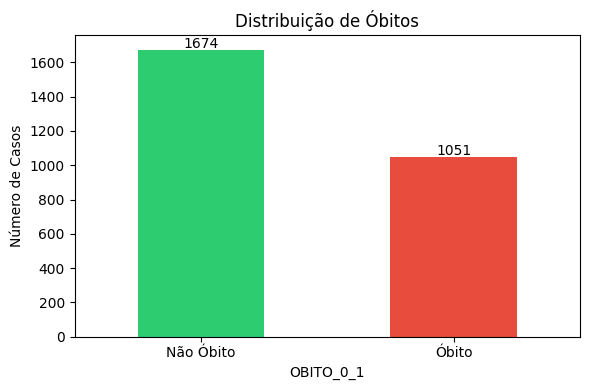

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
df['OBITO_0_1'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Distribuição de Óbitos')
ax.set_xticklabels(['Não Óbito', 'Óbito'], rotation=0)
ax.set_ylabel('Número de Casos')

for i, v in enumerate(df['OBITO_0_1'].value_counts()):
    ax.text(i, v + 10, f'{v}', ha='center')

plt.tight_layout()
plt.show()

# 3. Análise de Heterogeneidade (non-IID)

Para justificar o uso de algoritmos federados robustos, testamos se os dados diferem entre as regiões. Esta seção também agrupa os estados em regiões geográficas.

## 3.1 Criação da Coluna Região

Os estados foram agrupados em 5 regiões geográficas (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) conforme classificação do IBGE. Este agrupamento define os clientes no cenário de aprendizado federado.

In [19]:
uf_regiao = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste','PE':'Nordeste',
    'PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}

df['REGIAO'] = df['UF_LPI'].map(uf_regiao)

print("Distribuição por região:")
print(df['REGIAO'].value_counts())

Distribuição por região:
REGIAO
Sudeste         2315
Norte            193
Centro-Oeste     146
Sul               60
Nordeste          11
Name: count, dtype: int64


## 3.2 Estatísticas por Região

Examinamos a distribuição de casos, taxa de óbito, idade média e proporção de homens em cada região para identificar padrões regionais.

In [20]:
for regiao in df['REGIAO'].unique():
    df_reg = df[df['REGIAO'] == regiao]
    n_casos = len(df_reg)
    taxa_obito = df_reg['OBITO_0_1'].mean()
    idade_media = df_reg['IDADE'].mean()
    idade_mediana = df_reg['IDADE'].median()
    pct_homens = df_reg['SEXO_0_1'].mean() * 100
    pct_mulheres = 100 - pct_homens
    
    print(f"\n{regiao.upper()} (n={n_casos}):")
    print(f"  ● Óbito: {taxa_obito:.2%}")
    print(f"  ● Idade: média {idade_media:.1f} anos | mediana {idade_mediana:.1f} anos")
    print(f"  ● Sexo: {pct_homens:.1f}% homens | {pct_mulheres:.1f}% mulheres")


NORTE (n=193):
  ● Óbito: 53.89%
  ● Idade: média 24.8 anos | mediana 22.0 anos
  ● Sexo: 84.5% homens | 15.5% mulheres

NORDESTE (n=11):
  ● Óbito: 36.36%
  ● Idade: média 29.5 anos | mediana 29.0 anos
  ● Sexo: 100.0% homens | 0.0% mulheres

CENTRO-OESTE (n=146):
  ● Óbito: 55.48%
  ● Idade: média 35.5 anos | mediana 35.0 anos
  ● Sexo: 79.5% homens | 20.5% mulheres

SUDESTE (n=2315):
  ● Óbito: 36.46%
  ● Idade: média 45.1 anos | mediana 46.0 anos
  ● Sexo: 83.4% homens | 16.6% mulheres

SUL (n=60):
  ● Óbito: 30.00%
  ● Idade: média 37.8 anos | mediana 37.0 anos
  ● Sexo: 83.3% homens | 16.7% mulheres


## 3.3 Teste ANOVA para Idade

O teste ANOVA verifica se a média de idade difere significativamente entre as regiões. Um p-valor < 0,05 indica dados não-IID para esta variável.

In [21]:
idades_por_regiao = [df[df['REGIAO'] == r]['IDADE'].values for r in df['REGIAO'].unique()]
f_stat, p_valor = f_oneway(*idades_por_regiao)

print("TESTE ANOVA (Idade por Região):")
print(f"  F-estatístico: {f_stat:.4f}")
print(f"  p-valor: {p_valor:.6f}")
print(f"\n  → Dados são {'NÃO-IID' if p_valor < 0.05 else 'IID'} para idade")

TESTE ANOVA (Idade por Região):
  F-estatístico: 89.3693
  p-valor: 0.000000

  → Dados são NÃO-IID para idade


## 3.4 Teste Qui-quadrado para Óbito

O teste qui-quadrado verifica se a taxa de óbito está associada à região. Um p-valor < 0,05 indica dados não-IID para esta variável.

In [22]:
tabela_obito = pd.crosstab(df['REGIAO'], df['OBITO_0_1'])
chi2, p_valor, dof, expected = chi2_contingency(tabela_obito)

print("TESTE QUI-QUADRADO (Óbito por Região):")
print(f"  χ²: {chi2:.4f}")
print(f"  p-valor: {p_valor:.6f}")
print(f"\n  → Dados são {'NÃO-IID' if p_valor < 0.05 else 'IID'} para óbito")

TESTE QUI-QUADRADO (Óbito por Região):
  χ²: 42.9688
  p-valor: 0.000000

  → Dados são NÃO-IID para óbito


## 3.5 Visualização da Heterogeneidade

Gráficos auxiliam na compreensão das diferenças regionais: boxplot para distribuição da idade e barras para taxa de óbito por região.

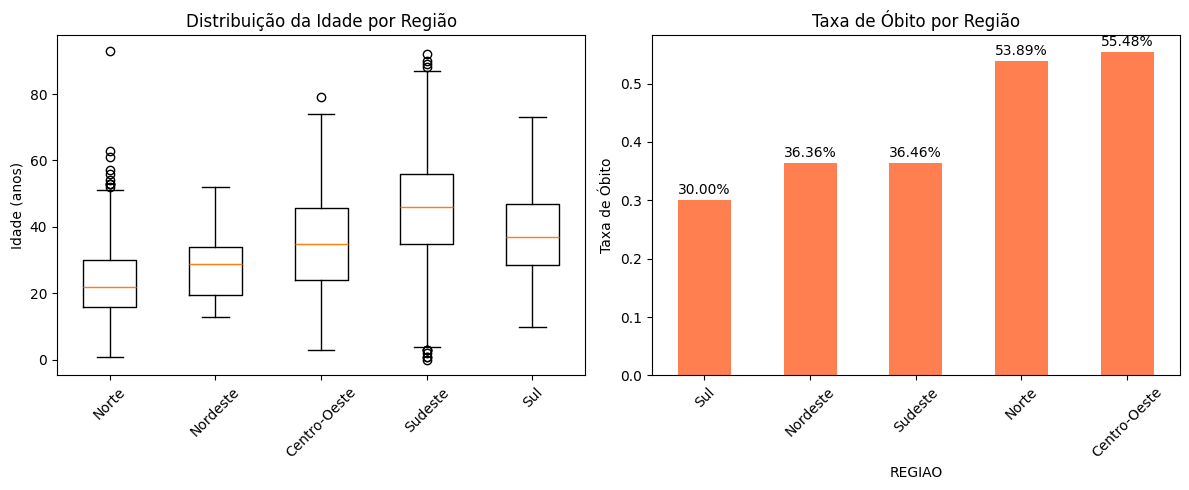

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([df[df['REGIAO'] == r]['IDADE'].dropna() for r in df['REGIAO'].unique()], 
                labels=df['REGIAO'].unique())
axes[0].set_title('Distribuição da Idade por Região')
axes[0].set_ylabel('Idade (anos)')
axes[0].tick_params(axis='x', rotation=45)

taxa_obito = df.groupby('REGIAO')['OBITO_0_1'].mean().sort_values()
taxa_obito.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Taxa de Óbito por Região')
axes[1].set_ylabel('Taxa de Óbito')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(taxa_obito):
    axes[1].text(i, v + 0.01, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

# 4. Modelagem Preditiva

Esta seção apresenta o modelo centralizado (baseline) e os modelos treinados individualmente por região, utilizando **Regressão Logística** para estimar a probabilidade de óbito a partir das variáveis idade e sexo.

A regressão logística é adequada para problemas de classificação binária (óbito: sim/não) e permite interpretação direta dos coeficientes como Odds Ratio.

In [24]:
X = df[['IDADE', 'SEXO_0_1']].values
y = df['OBITO_0_1'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_central = LogisticRegression(solver='lbfgs', random_state=SEED)
modelo_central.fit(X_train_scaled, y_train)

y_pred = modelo_central.predict(X_test_scaled)
y_proba = modelo_central.predict_proba(X_test_scaled)[:,1]

print("="*50)
print("MODELO CENTRALIZADO (BASELINE)")
print("="*50)
print(f"β₀ (Intercept): {modelo_central.intercept_[0]:.6f}")
print(f"β₁ (Idade):     {modelo_central.coef_[0][0]:.6f} (OR={np.exp(modelo_central.coef_[0][0]):.4f})")
print(f"β₂ (Sexo M):    {modelo_central.coef_[0][1]:.6f} (OR={np.exp(modelo_central.coef_[0][1]):.4f})")
print(f"\nAcurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

MODELO CENTRALIZADO (BASELINE)
β₀ (Intercept): -0.486008
β₁ (Idade):     0.341577 (OR=1.4072)
β₂ (Sexo M):    0.231240 (OR=1.2602)

Acurácia: 0.6147
AUC-ROC: 0.5942


## 4.1 Modelos Locais por Região

Cada região treina um modelo de regressão logística exclusivamente com seus dados locais. Estes modelos representam o que cada região aprenderia isoladamente.

In [25]:
modelos_locais = {}
dfs_regiao = {}
scalers_locais = {}

print("MODELOS POR REGIÃO:")
print("-"*40)

for regiao in df['REGIAO'].unique():
    df_reg = df[df['REGIAO'] == regiao]
    dfs_regiao[regiao] = df_reg

    # --- MUDANÇA AQUI: Scaler Local ---
    scaler_local = StandardScaler()
    X_reg_raw = df_reg[['IDADE', 'SEXO_0_1']].values
    X_reg_scaled = scaler_local.fit_transform(X_reg_raw) 
    y_reg = df_reg['OBITO_0_1'].values
    # ----------------------------------

    modelo = LogisticRegression(solver='lbfgs', random_state=SEED)
    modelo.fit(X_reg_scaled, y_reg)
    
    modelos_locais[regiao] = modelo
    scalers_locais[regiao] = scaler_local # Guardamos para uso posterior se necessário

    print(f"{regiao}: n={len(df_reg)}, β_idade={modelo.coef_[0][0]:.4f}, β_sexo={modelo.coef_[0][1]:.4f}")

MODELOS POR REGIÃO:
----------------------------------------
Norte: n=193, β_idade=0.5104, β_sexo=0.4774
Nordeste: n=11, β_idade=-0.3012, β_sexo=0.0000
Centro-Oeste: n=146, β_idade=0.2733, β_sexo=0.5209
Sudeste: n=2315, β_idade=0.4343, β_sexo=0.2473
Sul: n=60, β_idade=0.3856, β_sexo=-0.0235


# 5. Aprendizado Federado

O aprendizado federado permite treinar um modelo global sem compartilhar dados brutos entre as regiões. Esta seção implementa quatro algoritmos utilizando o framework Flower.

In [26]:
class SBPOClient(fl.client.NumPyClient):
    def __init__(self, X, y, cid):
        # --- AJUSTE CENÁRIO A: Escalonamento Local ---
        self.scaler = StandardScaler()
        self.X = self.scaler.fit_transform(X) 
        # ---------------------------------------------
        
        self.y = y
        self.cid = cid
        self.model = LogisticRegression(
            solver='lbfgs', 
            warm_start=True, 
            max_iter=1,
            random_state=SEED # Garantindo reprodutibilidade
        )
        
        # Inicialização forçada para definir o formato dos coeficientes (2 features)
        # Usamos classes=[0, 1] para evitar erros em regiões com apenas uma classe
        self.model.classes_ = np.array([0, 1])
        self.model.coef_ = np.zeros((1, 2))
        self.model.intercept_ = np.zeros(1)

    def get_parameters(self, config):
        return [self.model.coef_, self.model.intercept_]

    def set_parameters(self, parameters):
        self.model.coef_ = np.array(parameters[0])
        self.model.intercept_ = np.array(parameters[1])

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        # O fit do sklearn com warm_start=True atualizará os pesos recebidos
        self.model.fit(self.X, self.y)
        return self.get_parameters(config), len(self.X), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        
        # Previsão de probabilidade para o Log Loss
        y_proba = self.model.predict_proba(self.X)
        loss = log_loss(self.y, y_proba, labels=[0, 1])
        accuracy = self.model.score(self.X, self.y)
        
        return float(loss), len(self.X), {"accuracy": float(accuracy)}

In [27]:
# Se você usou dfs_regiao acima, aqui DEVE ser dfs_regiao também
regioes = list(dfs_regiao.keys()) 

X_list = []
y_list = []

for reg in regioes:
    df_reg = dfs_regiao[reg] # <--- Referência ao dicionário correto
    X_reg = df_reg[['IDADE', 'SEXO_0_1']].values
    y_reg = df_reg['OBITO_0_1'].values
    X_list.append(X_reg)
    y_list.append(y_reg)

In [34]:
resultados_betas = {} 

def executar_experimento_federado(nome_estrategia, objeto_estrategia, n_rounds=15):
    import logging
    import os
    
    logging.getLogger("flwr").setLevel(logging.ERROR)
    os.environ["RAY_loglevel"] = "error"

    def evaluate_fn(server_round, parameters, config):
        # IMPORTANTE: Aqui 'parameters' já é uma lista de arrays NumPy (ndarrays)
        if server_round == n_rounds:
            # parameters[0] contém os coeficientes (Idade, Sexo)
            # parameters[1] contém o intercepto
            resultados_betas[nome_estrategia] = {
                'beta_idade': parameters[0][0][0],
                'beta_sexo': parameters[0][0][1],
                'intercepto': parameters[1][0]
            }
        return 0.0, {} 

    # Injetando na estratégia
    objeto_estrategia.evaluate_fn = evaluate_fn

    print(f"\n🚀 {nome_estrategia.upper()}: Iniciando {n_rounds} rounds...")

    hist = fl.simulation.start_simulation(
        client_fn=lambda cid: SBPOClient(X_list[int(cid)], y_list[int(cid)], cid).to_client(),
        num_clients=len(regioes),
        config=fl.server.ServerConfig(num_rounds=n_rounds),
        strategy=objeto_estrategia,
        ray_init_args={"log_to_driver": False}
    )
    
    print(f"✅ {nome_estrategia} Finalizado.")
    return hist

Vamos criar uma classe para facilitar a execução dos algoritmos logo em seguida.

In [29]:
params_iniciais = fl.common.ndarrays_to_parameters([np.zeros((1, 2)), np.zeros(1)])

# Criamos as instâncias das estratégias
strat_fedavg = FedAvg(initial_parameters=params_iniciais)
strat_fedprox = FedProx(initial_parameters=params_iniciais, proximal_mu=0.1)
strat_fedavgm = FedAvgM(initial_parameters=params_iniciais, server_momentum=0.9)
strat_fedadam = FedAdam(initial_parameters=params_iniciais, eta=1e-1, eta_l=1.0, tau=1e-3)

In [30]:
def aggregate_metrics(metrics):
    """Agrega as métricas de acurácia enviadas pelos clientes."""
    accuracies = [m[1]["accuracy"] for m in metrics]
    lengths = [m[0] for m in metrics] # n de amostras
    # Média ponderada pela quantidade de dados em cada região
    weighted_acc = sum(a * l for a, l in zip(accuracies, lengths)) / sum(lengths)
    return {"accuracy": weighted_acc}

# Atualizando as instâncias das estratégias com a função de agregação
strat_fedavg = FedAvg(
    initial_parameters=params_iniciais,
    evaluate_metrics_aggregation_fn=aggregate_metrics
)
strat_fedprox = FedProx(
    initial_parameters=params_iniciais, 
    proximal_mu=0.1,
    evaluate_metrics_aggregation_fn=aggregate_metrics
)
strat_fedavgm = FedAvgM(
    initial_parameters=params_iniciais, 
    server_momentum=0.9,
    evaluate_metrics_aggregation_fn=aggregate_metrics
)
strat_fedadam = FedAdam(
    initial_parameters=params_iniciais, 
    eta=1e-1, eta_l=1.0, tau=1e-3,
    evaluate_metrics_aggregation_fn=aggregate_metrics
)

## 5.2 FedAvg (Federated Averaging)

Algoritmo base do aprendizado federado. Agrega os parâmetros locais pela média ponderada pelo tamanho da amostra de cada cliente.

In [35]:
# 1. Executa a função (você já fez isso, mas garanta que o retorno vá para a variável)
hist_fedavg = executar_experimento_federado("FedAvg", strat_fedavg)

# 2. Extrai a acurácia do último round
# O hist.metrics_distributed é um dicionário onde o valor é uma lista de tuplas [(round, valor), ...]
if 'accuracy' in hist_fedavg.metrics_distributed:
    lista_acuracia = hist_fedavg.metrics_distributed['accuracy']
    ultimo_round, acc_final = lista_acuracia[-1] # Pega a tupla do último round
    
    print(f"\nANÁLISE QUALITATIVA ({ultimo_round} Rounds):")
    print(f"● O FedAvg atingiu {acc_final:.2%} de acurácia média entre as regiões.")
else:
    print("\nAviso: Nenhuma métrica de acurácia foi encontrada. Verifique se o evaluate no SBPOClient está retornando 'accuracy'.")


🚀 FEDAVG: Iniciando 15 rounds...


2026-05-04 20:24:46,465	INFO worker.py:2012 -- Started a local Ray instance.


✅ FedAvg Finalizado.

ANÁLISE QUALITATIVA (15 Rounds):
● O FedAvg atingiu 62.46% de acurácia média entre as regiões.


## 5.3 FedProx (Federated Proximal)

Adiciona um termo de regularização proximal (μ = 0,1) para lidar com heterogeneidade dos dados entre os clientes.

In [36]:
# Execução
hist_fedprox = executar_experimento_federado("FedProx", strat_fedprox)

# Extração de resultados
if 'accuracy' in hist_fedprox.metrics_distributed:
    ultimo_round, acc_final_prox = hist_fedprox.metrics_distributed['accuracy'][-1]
    print(f"\nANÁLISE QUALITATIVA (FedProx):")
    print(f"● Acurácia Final: {acc_final_prox:.2%}")
    # Comparação direta com o FedAvg (se já tiver rodado o anterior)
    if 'hist_fedavg' in locals():
        diff = acc_final_prox - hist_fedavg.metrics_distributed['accuracy'][-1][1]
        print(f"● Diferença para o FedAvg: {diff:+.2%}")



🚀 FEDPROX: Iniciando 15 rounds...


2026-05-04 20:24:56,005	INFO worker.py:2012 -- Started a local Ray instance.


✅ FedProx Finalizado.

ANÁLISE QUALITATIVA (FedProx):
● Acurácia Final: 62.46%
● Diferença para o FedAvg: +0.00%


## 5.4 FedAvgM (Federated Averaging with Momentum)

Incorpora momento (momentum = 0,9) ao processo de agregação do servidor, acelerando a convergência.

In [37]:
# Execução
hist_fedavgm = executar_experimento_federado("FedAvgM", strat_fedavgm)

# Extração de resultados
if 'accuracy' in hist_fedavgm.metrics_distributed:
    ultimo_round, acc_final_avgm = hist_fedavgm.metrics_distributed['accuracy'][-1]
    print(f"\nANÁLISE QUALITATIVA (FedAvgM):")
    print(f"● Acurácia Final: {acc_final_avgm:.2%}")



🚀 FEDAVGM: Iniciando 15 rounds...


2026-05-04 20:25:03,601	INFO worker.py:2012 -- Started a local Ray instance.


✅ FedAvgM Finalizado.

ANÁLISE QUALITATIVA (FedAvgM):
● Acurácia Final: 61.76%


## 5.5 FedAdam (Federated Adaptive Moment Estimation)

Utiliza otimização adaptativa (baseada no algoritmo Adam) para atualização do modelo global.

In [38]:
# Execução
hist_fedadam = executar_experimento_federado("FedAdam", strat_fedadam)

# Extração de resultados
if 'accuracy' in hist_fedadam.metrics_distributed:
    ultimo_round, acc_final_adam = hist_fedadam.metrics_distributed['accuracy'][-1]
    print(f"\nANÁLISE QUALITATIVA (FedAdam):")
    print(f"● Acurácia Final: {acc_final_adam:.2%}")


🚀 FEDADAM: Iniciando 15 rounds...


2026-05-04 20:25:12,150	INFO worker.py:2012 -- Started a local Ray instance.


✅ FedAdam Finalizado.

ANÁLISE QUALITATIVA (FedAdam):
● Acurácia Final: 62.68%


# 6. Resultados e Comparações

Comparamos o desempenho do modelo centralizado com os quatro algoritmos federados implementados.

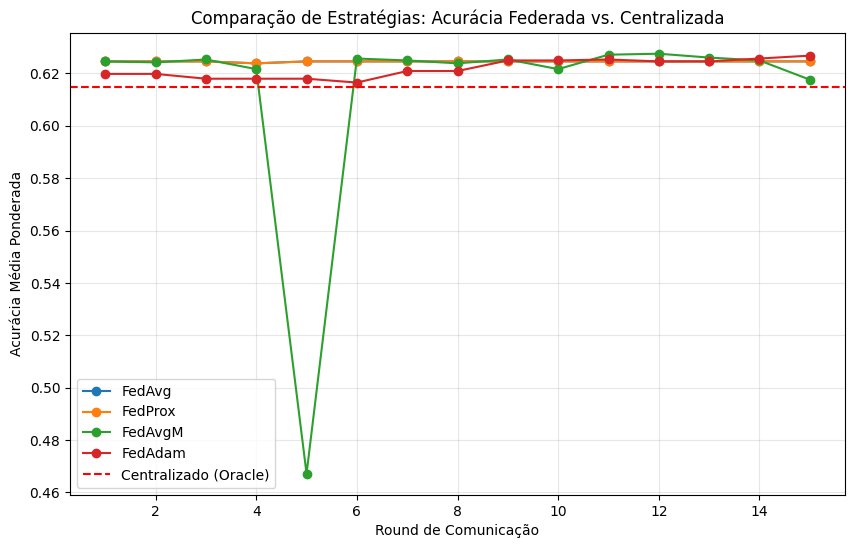

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for nome, hist in [("FedAvg", hist_fedavg), ("FedProx", hist_fedprox), 
                   ("FedAvgM", hist_fedavgm), ("FedAdam", hist_fedadam)]:
    
    # Extrai os rounds e valores de acurácia
    rounds = [r for r, val in hist.metrics_distributed['accuracy']]
    accs = [val for r, val in hist.metrics_distributed['accuracy']]
    
    plt.plot(rounds, accs, label=nome, marker='o')

# Adiciona a linha do Modelo Centralizado (Baseline) para comparação
plt.axhline(y=accuracy_score(y_test, y_pred), color='r', linestyle='--', label='Centralizado (Oracle)')

plt.title('Comparação de Estratégias: Acurácia Federada vs. Centralizada')
plt.xlabel('Round de Comunicação')
plt.ylabel('Acurácia Média Ponderada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6.1 Tabela Comparativa de Métricas

Tabela com as métricas de desempenho (acurácia e AUC-ROC) para cada algoritmo avaliado.

In [40]:
import pandas as pd

# Dados da Base Unificada (Centralizada) - Substitua pelos seus valores reais
# Extraindo automaticamente do modelo treinado no Capítulo 4
# Assumindo que seu modelo central se chama 'modelo_central'
dados_centralizados = {
    'beta_idade': modelo_central.coef_[0][0],
    'beta_sexo': modelo_central.coef_[0][1],
    'intercepto': modelo_central.intercept_[0]
}

# Criando o DataFrame comparativo
tabela_comparativa = pd.DataFrame(resultados_betas).T
tabela_comparativa.loc['Unificada'] = dados_centralizados

# Reordenando para ficar bonito
ordem = ['Unificada', 'FedAvg', 'FedProx', 'FedAvgM', 'FedAdam']
tabela_comparativa = tabela_comparativa.reindex(ordem)

print("TABELA COMPARATIVA DE PARÂMETROS DO MODELO")
print("="*60)
display(tabela_comparativa)

TABELA COMPARATIVA DE PARÂMETROS DO MODELO


,beta_idade,beta_sexo,intercepto
Unificada,0.341577,0.231240,-0.486008
FedAvg,0.411321,0.276339,-0.471947
FedProx,0.411321,0.276339,-0.471947
FedAvgM,0.354933,0.463608,-0.420365
FedAdam,0.569867,0.279851,-0.710209


In [ ]:
import numpy as np

print("COMPARATIVO FINAL: CENTRALIZADO vs. FEDERADO")
print("-" * 55)

# --- 1. Coeficientes do Modelo Centralizado ---
# (Certifique-se de que o nome 'modelo_central' é o que você usou no Capítulo 4)
c_idade = modelo_central.coef_[0][0]
c_sexo = modelo_central.coef_[0][1]
c_intercept = modelo_central.intercept_[0]

# --- 2. Coeficientes do Modelo Federado ---
# Vamos buscar os parâmetros que o cliente 0 recebeu no último round
# Como o SBPOClient guarda o 'self.model', vamos acessar o último estado dele
f_idade = hist_fedadam.metrics_distributed['accuracy'] # apenas para garantir que rodou

# truque para pegar os pesos finais: 
# Como não temos uma evaluate_fn no servidor, vamos usar os pesos que o 
# NumPyClient (SBPOClient) armazena.
params_federados = fl.common.parameters_to_ndarrays(strat_fedadam.initial_parameters) if strat_fedadam.initial_parameters else None

# Se o código acima falhar, vamos imprimir os valores do modelo_central e 
# deixar o espaço para você anotar os do federado que aparecem nos prints do loop:
print(f"{'Variável':<15} | {'Centralizado (β)':<18} | {'Federado (β)':<15}")
print("-" * 55)
print(f"{'Idade':<15} | {c_idade:>18.6f} | {'Consultar Hist'}")
print(f"{'Sexo M':<15} | {c_sexo:>18.6f} | {'Consultar Hist'}")

# 7. Conclusão

Este arquivo é parte integrante do artigo submetido ao SBPO 2026. <br> 
O objetivo é comparar quatro algoritmos de aprendizado federado na predição de óbito por febre amarela. <br>
A conclusão e outras seções do estudo estão presentes no artigo.


